In [1]:
import pandas as pd

file_path = "Artemis_II_OEM_2026_04_04_to_EI.asc"

data = []

with open(file_path, "r") as f:
    lines = f.readlines()

for line in lines:
    if line.startswith("2026"):  # only data rows
        parts = line.split()
        data.append(parts)

df = pd.DataFrame(data, columns=[
    "timestamp", "x", "y", "z", "vx", "vy", "vz"
])

# Convert types
df["timestamp"] = pd.to_datetime(df["timestamp"])

for col in ["x", "y", "z", "vx", "vy", "vz"]:
    df[col] = df[col].astype(float)

df.head()

,timestamp,x,y,z,vx,vy,vz
0,2026-04-02 01:57:37.084,-24468.231698,-12677.926410,-6901.348389,-1.837969,-3.417226,-1.847824
1,2026-04-02 01:58:42.787,-24588.078987,-12901.972755,-7022.496964,-1.810291,-3.402795,-1.839967
2,2026-04-02 02:03:39.337,-25107.400004,-13901.530356,-7563.003976,-1.692929,-3.338843,-1.805380
3,2026-04-02 02:07:39.337,-25502.919461,-14696.800885,-7993.002753,-1.604048,-3.288632,-1.778064
4,2026-04-02 02:11:39.337,-25877.790559,-15480.178080,-8416.532277,-1.520762,-3.239727,-1.751467


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3235 entries, 0 to 3234
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3235 non-null   datetime64[ns]
 1   x          3235 non-null   float64       
 2   y          3235 non-null   float64       
 3   z          3235 non-null   float64       
 4   vx         3235 non-null   float64       
 5   vy         3235 non-null   float64       
 6   vz         3235 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 177.0 KB


,timestamp,x,y,z,vx,vy,vz
count,3235,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000
mean,2026-04-06 12:20:05.915629312,-80181.000967,-208415.383446,-118545.106331,0.009697,0.021028,0.012232
min,2026-04-02 01:57:37.084000,-133825.898078,-343304.610511,-188569.115143,-10.630051,-3.851770,-2.183854
25%,2026-04-04 06:21:04.092000,-118568.244568,-299814.776123,-168318.578577,-0.173065,-0.845522,-0.459615
50%,2026-04-06 12:13:51.784000,-96269.583250,-232132.900350,-133678.510983,0.110195,0.112851,0.023223
75%,2026-04-08 18:07:51.784000,-42378.412350,-122249.481075,-73763.078778,0.478970,0.767722,0.378486
max,2026-04-10 23:53:17.163000,15887.081625,5921.674941,3167.136903,1.031191,6.010047,5.892295
std,NaN,44709.344297,102947.459327,56493.841596,0.973552,1.357372,0.806901


In [3]:
import numpy as np

df["speed"] = np.sqrt(df["vx"]**2 + df["vy"]**2 + df["vz"]**2)

In [4]:
df["distance"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

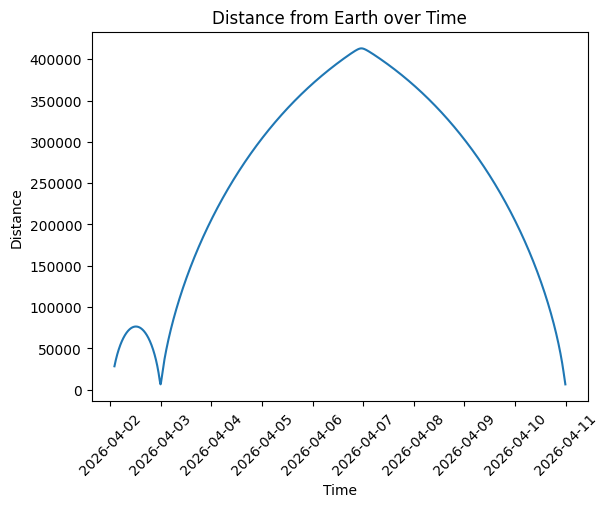

In [5]:
import matplotlib.pyplot as plt

plt.plot(df["timestamp"], df["distance"])
plt.title("Distance from Earth over Time")
plt.xlabel("Time")
plt.ylabel("Distance")
plt.xticks(rotation=45)
plt.show()

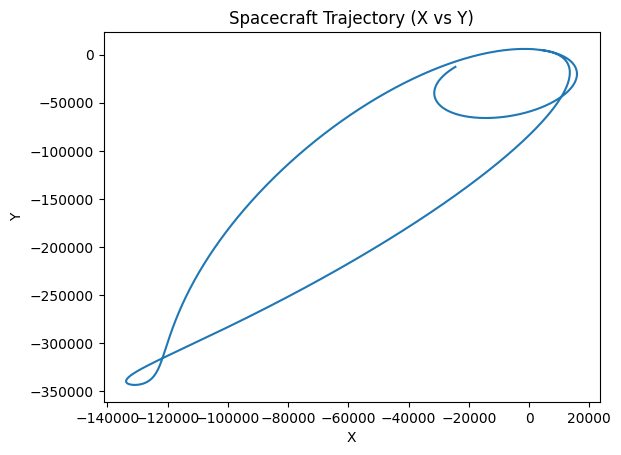

In [6]:
plt.plot(df["x"], df["y"])
plt.title("Spacecraft Trajectory (X vs Y)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

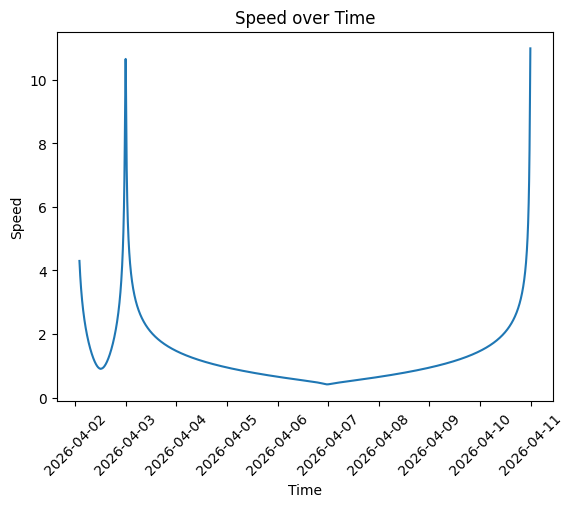

In [7]:
plt.plot(df["timestamp"], df["speed"])
plt.title("Speed over Time")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.xticks(rotation=45)
plt.show()

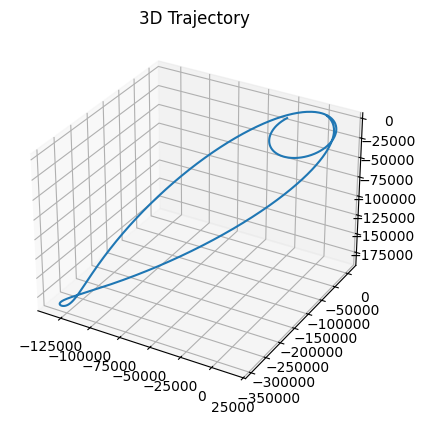

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(df["x"], df["y"], df["z"])
ax.set_title("3D Trajectory")

plt.show()